In [73]:
import torch 
import numpy as np 
import matplotlib.pyplot as plt
from itertools import islice
import json

from cryo_sbi.wpa_simulator.cryo_em_simulator import cryo_em_simulator
from cryo_sbi import CryoEmSimulator
from cryo_sbi.inference.models import build_models
import cryo_sbi.utils.estimator_utils as est_utils
from cryo_sbi.inference.priors import get_image_priors, PriorLoader

In [74]:
models = torch.load("models.pt")
image_config = "simulation_parameters.json"
simulation_batch_size = 160
n_workers=4
device="cuda"
BATCH_SIZE = 32

In [75]:
estimator = est_utils.load_estimator(
    "training_parameters_nle.json",
    build_models.build_nle_flow_model,
    "tutorial_estimator.pt",
    device="cuda",
)

In [76]:
estimator

NLEWithEmbedding(
  (nle): NPE(
    (flow): NSF(
      (transform): LazyComposedTransform(
        (0-4): 5 x ElementWiseTransform(
          (base): MonotonicRQSTransform(bins=8)
          (hyper): MLP(
            (0): Linear(in_features=128, out_features=128, bias=True)
            (1): LeakyReLU(negative_slope=0.1)
            (2): Linear(in_features=128, out_features=128, bias=True)
            (3): LeakyReLU(negative_slope=0.1)
            (4): Linear(in_features=128, out_features=128, bias=True)
            (5): LeakyReLU(negative_slope=0.1)
            (6): Linear(in_features=128, out_features=128, bias=True)
            (7): LeakyReLU(negative_slope=0.1)
            (8): Linear(in_features=128, out_features=128, bias=True)
            (9): LeakyReLU(negative_slope=0.1)
            (10): Linear(in_features=128, out_features=128, bias=True)
            (11): LeakyReLU(negative_slope=0.1)
            (12): Linear(in_features=128, out_features=64, bias=True)
            (13): Leak

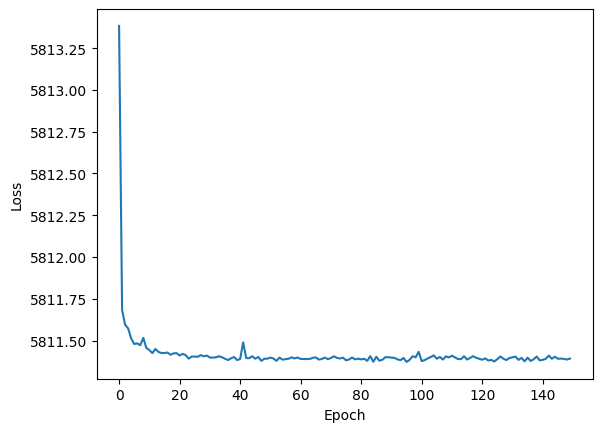

In [77]:
plt.plot(torch.load("tutorial.loss"))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [78]:
image_config = json.load(open(image_config))
image_prior = get_image_priors(len(models) - 1, image_config, device="cpu")
prior_loader = PriorLoader(
image_prior, batch_size=simulation_batch_size, num_workers=n_workers
    )

num_pixels = torch.tensor(
image_config["N_PIXELS"], dtype=torch.float32, device=device
)
pixel_size = torch.tensor(
image_config["PIXEL_SIZE"], dtype=torch.float32, device=device
)

In [79]:
estimator.eval()
log_probs_list = []

for parameters in islice(prior_loader, 100):  # same as training
    indices, quaternions, res, shift, defocus, b_factor, amp, snr = parameters

    # Regenerate images on-the-fly
    images = cryo_em_simulator(
            models,
            indices.to("cpu"),  # keep CPU for indexing
            quaternions.to("cpu"),
            res.to("cpu"),
            shift.to("cpu"),
            defocus.to("cpu"),
            b_factor.to("cpu"),
            amp.to("cpu"),
            snr.to("cpu"),
            num_pixels,
            pixel_size
        )

    # Compute pairwise log-probs batch by batch
    for _indices, _images in zip(indices.split(BATCH_SIZE), images.split(BATCH_SIZE)):
        theta_batch = models[_indices.round().long().flatten().cpu()]
        theta_batch = theta_batch.transpose(1, 2).to(device)  # move to GPU
        flat_images = _images.view(_images.size(0), -1).to(device)

        with torch.no_grad():
            posterior = estimator.flow(theta_batch.to(device))
            log_probs_batch = posterior.log_prob(flat_images.to(device))

        log_probs_list.append(log_probs_batch.cpu())

# Concatenate all batches
log_probs_training_style = torch.cat(log_probs_list, dim=0)
print(log_probs_training_style.shape)


torch.Size([16000])


In [80]:
np.shape(log_probs_list)

(500, 32)

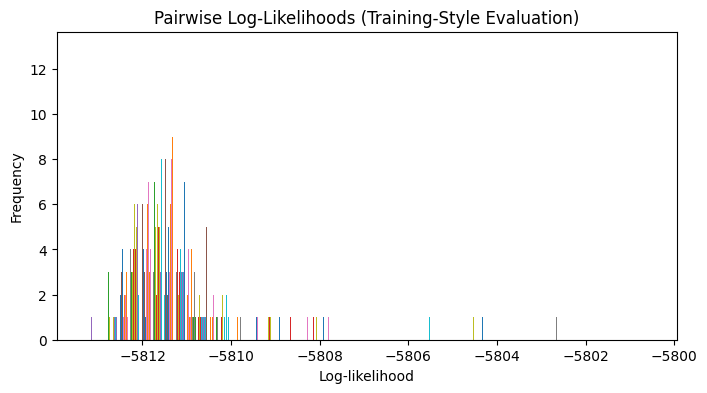

In [56]:
plt.figure(figsize=(8,4))
plt.hist(log_probs_list, bins=50)
plt.xlabel("Log-likelihood")
plt.ylabel("Frequency")
plt.title("Pairwise Log-Likelihoods (Training-Style Evaluation)")
plt.show()


In [57]:
np.shape(log_probs_list)

(500, 32)

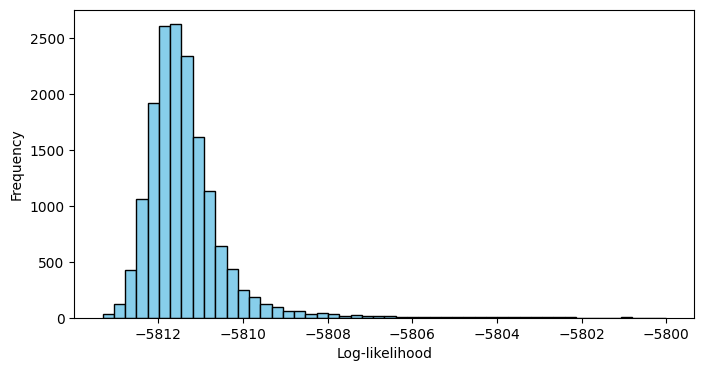

In [81]:
plt.figure(figsize=(8,4))
plt.hist(log_probs_training_style, bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Log-likelihood")
plt.ylabel("Frequency")
plt.show()


In [82]:
np.shape(log_probs_list)

(500, 32)

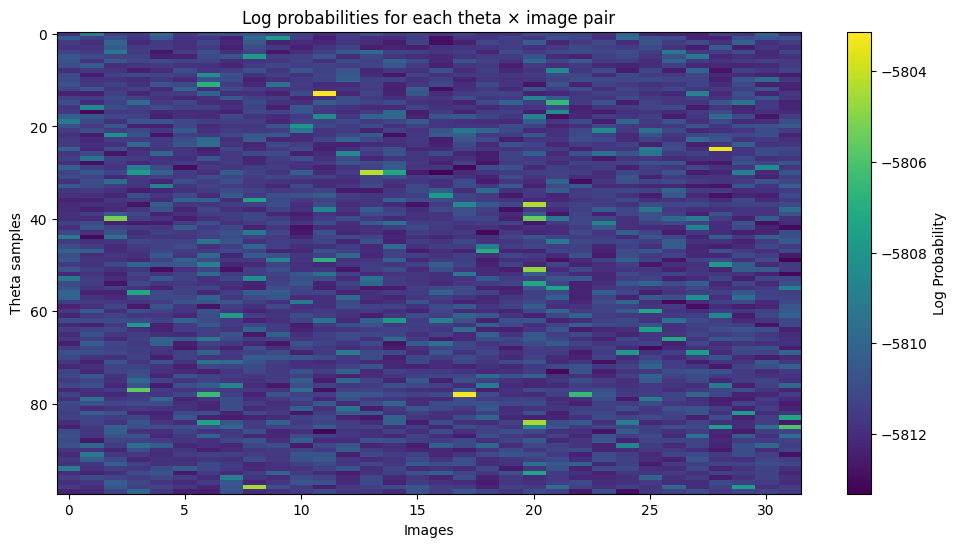

In [83]:


# log_probs: [num_thetas, num_images]
plt.figure(figsize=(12, 6))
plt.imshow(log_probs_list[:100], aspect='auto', cmap='viridis')
#plt.imshow(log_probs[:, ::300].cpu().numpy(), aspect='auto', cmap='viridis')
plt.colorbar(label='Log Probability')
plt.xlabel('Images')
plt.ylabel('Theta samples')
plt.title('Log probabilities for each theta × image pair')
plt.show()


In [84]:
import torch

def evaluate_log_prob_cartesian(
    estimator: torch.nn.Module,
    images: torch.Tensor,     # [num_images, ...]
    theta: torch.Tensor,      # [num_thetas, ...]
    device: str = "cuda",
    batch_size_theta: int = 16,
    batch_size_images: int = 128
) -> torch.Tensor:
    """
    Computes Cartesian log-probabilities for all θ × all images.

    Args:
        estimator (torch.nn.Module): Flow model to evaluate.
        images (torch.Tensor): Images to condition on. Shape [num_images, ...].
        theta (torch.Tensor): Parameter values. Shape [num_thetas, ...].
        device (str): Device for computation ("cuda" or "cpu").
        batch_size_theta (int): Batch size for θ to avoid OOM.
        batch_size_images (int): Batch size for images to avoid OOM.

    Returns:
        torch.Tensor: [num_thetas, num_images] log-likelihoods.
    """
    num_images = images.shape[0]
    flat_images = images.view(num_images, -1)  # flatten images

    num_thetas = theta.shape[0]
    log_probs_all = []

    for theta_batch in theta.split(batch_size_theta, dim=0):
        batch_log_probs = []

        for img_batch in flat_images.split(batch_size_images, dim=0):
            # Expand θ to match image batch
            theta_exp = theta_batch[:, None, ...]  # [Bθ, 1, ...]
            theta_exp = theta_exp.expand(-1, img_batch.shape[0], *theta_batch.shape[1:])  # [Bθ, Bimg, ...]
            theta_broadcast = theta_exp.reshape(-1, *theta_batch.shape[1:])  # flatten to 2D if needed

            # Expand images to match θ batch
            images_exp = img_batch[None, :, :].expand(theta_batch.shape[0], -1, img_batch.shape[1]).reshape(-1, img_batch.shape[1])

            with torch.no_grad():
                posterior = estimator.flow(theta_broadcast.to(device))
                log_probs = posterior.log_prob(images_exp.to(device))

            # Reshape back to [Bθ, Bimg]
            log_probs = log_probs.view(theta_batch.shape[0], img_batch.shape[0])
            batch_log_probs.append(log_probs.cpu())

        # Concatenate image batches along axis=1
        batch_log_probs = torch.cat(batch_log_probs, dim=1)  # [Bθ, num_images]
        log_probs_all.append(batch_log_probs)

    # Concatenate theta batches along axis=0
    log_probs_all = torch.cat(log_probs_all, dim=0)  # [num_thetas, num_images]
    return log_probs_all


In [85]:
simulator = CryoEmSimulator(
    "simulation_parameters.json"
)  # creating simulator with simulation parameters

images_eval, parameters = simulator.simulate(
    num_sim=5000, return_parameters=True
)  # simulating images and save parameters

side_length = parameters[0]  # extracting side_length from parameters
snr = parameters[-1]  # extracting snr from parameters

In [86]:
log_probs_cartesian = evaluate_log_prob_cartesian(
    estimator,
    images_eval,  # [num_images, H, W]
    models,   # [num_thetas, D]
    device="cuda",
    batch_size_theta=16,
    batch_size_images=64
)

print(log_probs_cartesian.shape)  # [num_thetas, num_images]


torch.Size([100, 5000])


In [87]:
log_probs = log_probs_cartesian.cpu().numpy() 

In [88]:
np.save('log_probs',log_probs)

In [89]:
np.save('log_probs_list',log_probs_list)


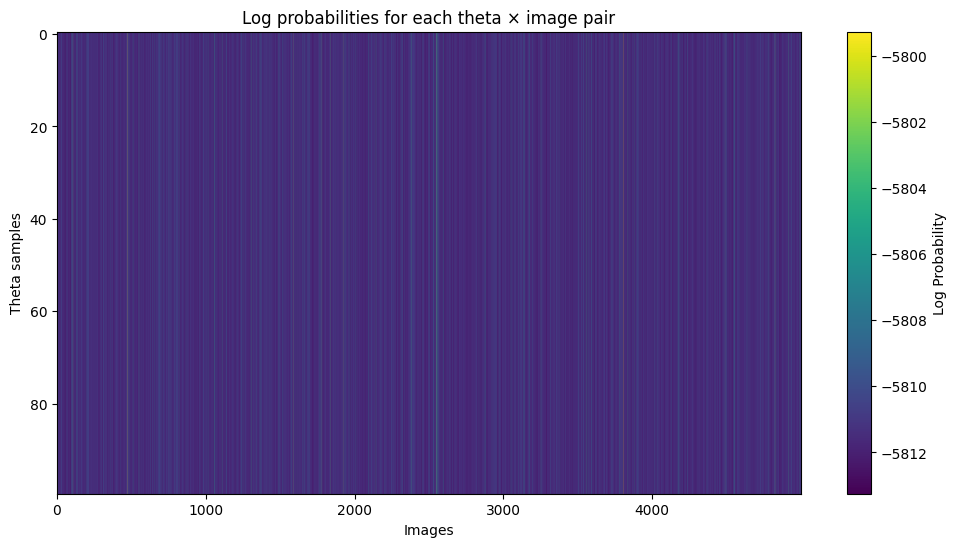

In [90]:


# log_probs: [num_thetas, num_images]
plt.figure(figsize=(12, 6))
plt.imshow(log_probs, aspect='auto', cmap='viridis')
#plt.imshow(log_probs[:, ::300].cpu().numpy(), aspect='auto', cmap='viridis')
plt.colorbar(label='Log Probability')
plt.xlabel('Images')
plt.ylabel('Theta samples')
plt.title('Log probabilities for each theta × image pair')
plt.show()


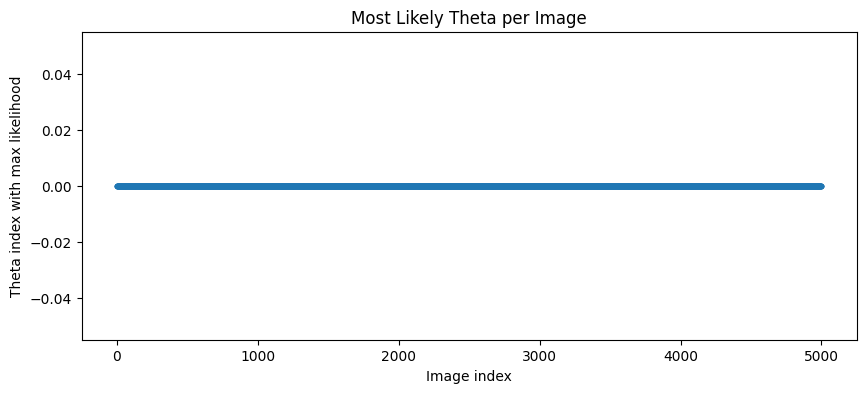

In [91]:
import torch

max_theta_indices = torch.argmax(log_probs_cartesian, dim=0)  # max over θ
plt.figure(figsize=(10,4))
plt.plot(max_theta_indices.numpy(), marker='o', linestyle='', markersize=3)
plt.xlabel('Image index')
plt.ylabel('Theta index with max likelihood')
plt.title('Most Likely Theta per Image')
plt.show()


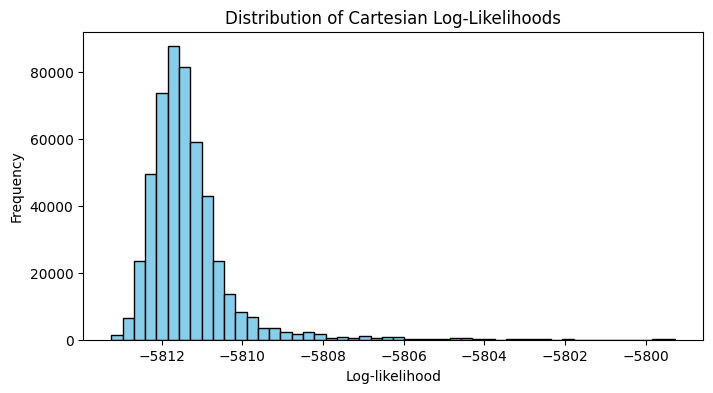

In [92]:
plt.figure(figsize=(8,4))
plt.hist(log_probs_cartesian.flatten().numpy(), bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Log-likelihood")
plt.ylabel("Frequency")
plt.title("Distribution of Cartesian Log-Likelihoods")
plt.show()


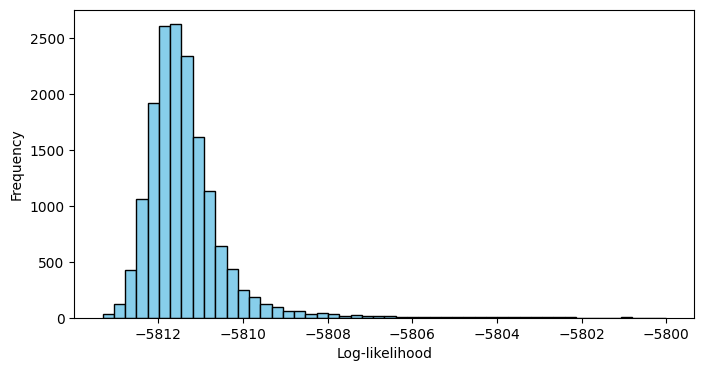

In [93]:
plt.figure(figsize=(8,4))
plt.hist(log_probs_training_style, bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Log-likelihood")
plt.ylabel("Frequency")
plt.show()


In [50]:
log_probs_training_style.shape

torch.Size([16000])